# TFM — Parque de Vehículos (DGT) vs. Renta de los Hogares (INE)
## Fase 3 — Análisis estadístico descriptivo

En el EDA (Fase 2) exploramos los datos. Aquí **cuantificamos** las hipótesis H1–H5 con
**estadística descriptiva**: agrupamos por segmento de renta y comparamos directamente
**medias, medianas y porcentajes** entre los grupos (sobre todo el extremo "Muy baja"
frente a "Muy alta").

Al final preparamos y exportamos **tablas agregadas y ligeras** para conectarlas a
**Power BI** sin problemas de rendimiento.

**Recorrido:** carga y limpieza → nota metodológica → H1 → H2 → H3 → H4 → H5 → resumen →
preparación y exportación para el dashboard.

---
## 0. Configuración e importaciones

In [1]:
%reload_ext autoreload
%autoreload 2

# ==============================================================================
# 1. LIBRERÍAS DE LA BIBLIOTECA ESTÁNDAR
# ==============================================================================
import sys
from pathlib import Path

# ==============================================================================
# 2. LIBRERÍAS DE TERCEROS (Data Science & Analytics)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ==============================================================================
# 3. RUTAS Y MÓDULOS PROPIOS
# ==============================================================================
DIR_PROCESSED = Path("../data/processed")
sys.path.append("../")
from src import tfm_io as ti   # Funciones de lectura/escritura (I/O)
from src import tfm_vis as tv  # Funciones de visualización y gráficos


# ==============================================================================
# 4. ESTÉTICA Y CONSTANTES
# ==============================================================================
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

ORDEN_SEG = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]

# Lista ILUSTRATIVA de marcas de gama alta (solo para el analisis, no se persiste en crudo)
GAMA_ALTA = ["MERCEDES-BENZ", "BMW", "AUDI", "VOLVO", "LEXUS", "PORSCHE",
             "JAGUAR", "LAND ROVER", "TESLA", "MINI", "DS", "ALFA ROMEO"]

---
## 1. Carga y preparación

Cargamos `dataset_procesado.parquet` y **re-aplicamos la limpieza de motor del EDA** (no se
guardó en el Parquet). Después nos quedamos con los coches de municipios con renta conocida
y creamos un par de columnas booleanas auxiliares para los porcentajes.

In [2]:
df = ti.cargar_parquet("dataset_procesado.parquet", DIR_PROCESSED)

Cargado exitosamente: 6,613,034 filas x 37 columnas


In [3]:
# --- Misma limpieza de motor del EDA (notebook 03) ---
df.loc[df["kw"].between(999, 1000).fillna(False), "kw"] = np.nan       # placeholder 999.99
mask_cil_nulo = (df["cilindrada"].eq(0) & ~df["es_electrificado"]).fillna(False)
df.loc[mask_cil_nulo, "cilindrada"] = pd.NA                            # cilindrada 0 en combustion
df.loc[df["kw"].eq(0).fillna(False), "kw"] = np.nan                    # kw 0 imposible
df.loc[df["kw"] > 800, "kw"] = np.nan                                  # tope 800 kW
df["kw"] = df["kw"].astype("float32")
df["potencia_cv"] = (df["kw"] * 1.35962).astype("float32")

# --- Subconjunto con renta conocida (municipios >= 10.000 hab.) ---
df_renta = df[df["tiene_municipio"]].copy()
df_renta["segmento_renta"] = df_renta["segmento_renta"].cat.remove_unused_categories()

# Pasamos cilindrada a float32 (asi la mediana y la media no dan problemas con el tipo nullable)
df_renta["cilindrada"] = df_renta["cilindrada"].astype("float32")

# Columnas booleanas auxiliares para calcular porcentajes con la media
df_renta["es_gama_alta"] = df_renta["marca"].isin(GAMA_ALTA)
df_renta["es_renting"] = df_renta["renting"].eq("SI")

print(f"Total: {len(df):,} | con renta conocida: {len(df_renta):,}")

Total: 6,613,034 | con renta conocida: 5,502,832


---
## 2. Nota metodológica: por qué un análisis descriptivo es suficiente

Nuestro dataset **no es una muestra: es prácticamente un censo** del parque de turismos de
las cinco provincias (están *todos* los vehículos matriculados, no una selección).

> 🟢 Esto es importante para entender por qué no usamos *tests* estadísticos. Los tests de
> inferencia sirven para **deducir cómo es una población
> que no podemos ver entera, a partir de una muestra pequeña**. Pero aquí sí vemos la
> población entera: tenemos todos los coches. Cuando tienes todos los datos, las **medias,
> medianas y porcentajes describen directamente la realidad**, sin necesidad de inferir nada.
> Por eso el análisis es 100% descriptivo y se puede defender con total seguridad.

El método para validar cada hipótesis es siempre el mismo: **agrupamos por
`segmento_renta`** (5 niveles, de "Muy baja" a "Muy alta") y comparamos el valor de cada
métrica entre los grupos, fijándonos especialmente en los dos extremos.

---
## 3. H1 — A mayor renta, ¿más potencia y cilindrada?

Agrupamos por segmento y calculamos la **media y la mediana** de potencia (CV) y cilindrada.

In [4]:
resumen_h1 = (df_renta.groupby("segmento_renta", observed=True)
              .agg(n_coches=("potencia_cv", "size"),
                   potencia_media=("potencia_cv", "mean"),
                   potencia_mediana=("potencia_cv", "median"),
                   cilindrada_media=("cilindrada", "mean"),
                   cilindrada_mediana=("cilindrada", "median"))
              .reindex(ORDEN_SEG).round(1))
display(resumen_h1)

# Comparacion directa entre extremos
pb, pa = resumen_h1.loc["Muy baja", "potencia_media"], resumen_h1.loc["Muy alta", "potencia_media"]
cb, ca = resumen_h1.loc["Muy baja", "cilindrada_media"], resumen_h1.loc["Muy alta", "cilindrada_media"]
print(f"Potencia media:   Muy baja {pb:.2f} CV  ->  Muy alta {pa:.2f} CV  ({(pa/pb-1)*100:+.2f}%)")
print(f"Cilindrada media: Muy baja {cb:.0f} cc  ->  Muy alta {ca:.0f} cc  ({(ca/cb-1)*100:+.2f}%)")

,n_coches,potencia_media,potencia_mediana,cilindrada_media,cilindrada_mediana
segmento_renta,,,,,
Muy baja,525008,121.300003,115.599998,1510.900024,1499.0
Baja,576500,122.099998,115.599998,1475.300049,1498.0
Media,1009945,122.800003,115.599998,1479.699951,1498.0
Alta,972820,125.099998,115.599998,1483.500000,1498.0
Muy alta,2418559,130.800003,119.599998,1489.699951,1498.0


Potencia media:   Muy baja 121.30 CV  ->  Muy alta 130.80 CV  (+7.83%)
Cilindrada media: Muy baja 1511 cc  ->  Muy alta 1490 cc  (-1.40%)


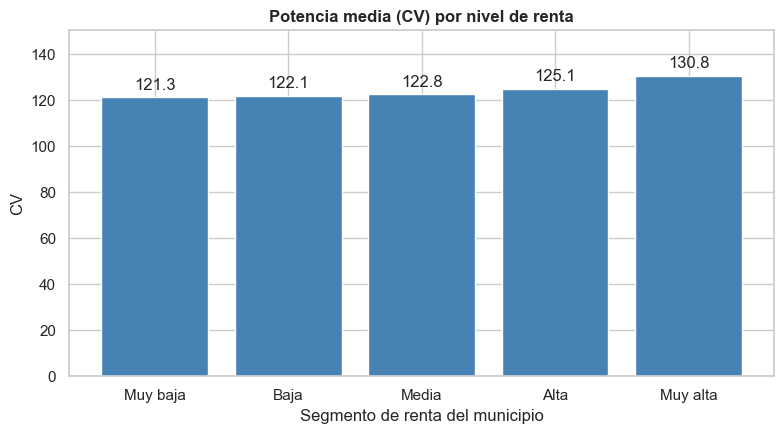

In [5]:
tv.barras_segmento(resumen_h1["potencia_media"], "Potencia media (CV) por nivel de renta", "CV")

> 🟢 **Qué esperamos ver:** la potencia sube de forma suave al subir la renta (unos pocos CV
> de diferencia entre extremos), mientras que la cilindrada se mantiene casi plana. Es decir,
> H1 se cumple solo a medias: los municipios con más renta tienen coches algo más potentes,
> pero no más cilindrada.

---
## 4. H2 — A mayor renta, ¿coches más nuevos?

Misma idea con la **antigüedad** (años desde la primera matriculación).

In [6]:
resumen_h2 = (df_renta.groupby("segmento_renta", observed=True)
              .agg(n_coches=("antiguedad", "size"),
                   antiguedad_media=("antiguedad", "mean"),
                   antiguedad_mediana=("antiguedad", "median"))
              .reindex(ORDEN_SEG).round(2))
display(resumen_h2)

ab, aa = resumen_h2.loc["Muy baja", "antiguedad_media"], resumen_h2.loc["Muy alta", "antiguedad_media"]
print(f"Antiguedad media: Muy baja {ab:.2f} años  ->  Muy alta {aa:.2f} años  ({aa-ab:+.2f} años)")



,n_coches,antiguedad_media,antiguedad_mediana
segmento_renta,,,
Muy baja,525008,8.49,8.53
Baja,576500,7.87,7.90
Media,1009945,7.90,7.93
Alta,972820,7.58,7.67
Muy alta,2418559,6.27,5.61


Antiguedad media: Muy baja 8.49 años  ->  Muy alta 6.27 años  (-2.22 años)


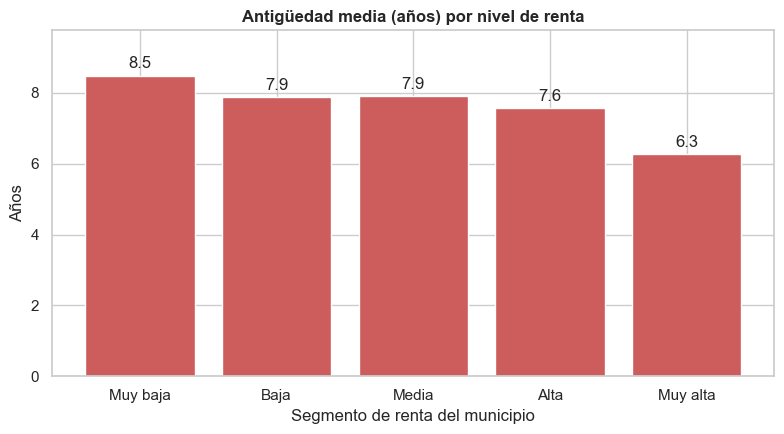

In [7]:
tv.barras_segmento(resumen_h2["antiguedad_media"], "Antigüedad media (años) por nivel de renta",
                "Años", color="indianred")

> 🟢 **Qué esperamos ver:** una bajada clara de la antigüedad al subir la renta (los coches
> de los municipios ricos son varios años más nuevos). Es la tendencia más limpia junto con
> la electrificación.

---
## 5. H3 — A mayor renta, ¿más coches electrificados?

`es_electrificado` es Sí/No, así que el **porcentaje** se calcula como la media de esa
columna booleana (`media × 100`).

In [8]:
resumen_h3 = (df_renta.groupby("segmento_renta", observed=True)["es_electrificado"]
              .agg(n_coches="size", pct_electrificado="mean")
              .reindex(ORDEN_SEG))
resumen_h3["pct_electrificado"] = (resumen_h3["pct_electrificado"] * 100).round(1)
display(resumen_h3)

eb, ea = resumen_h3.loc["Muy baja", "pct_electrificado"], resumen_h3.loc["Muy alta", "pct_electrificado"]
print(f"% electrificados: Muy baja {eb:.1f}%  ->  Muy alta {ea:.1f}%  (x{ea/eb:.1f})")

,n_coches,pct_electrificado
segmento_renta,,
Muy baja,525008,12.7
Baja,576500,16.6
Media,1009945,18.5
Alta,972820,21.2
Muy alta,2418559,31.4


% electrificados: Muy baja 12.7%  ->  Muy alta 31.4%  (x2.5)


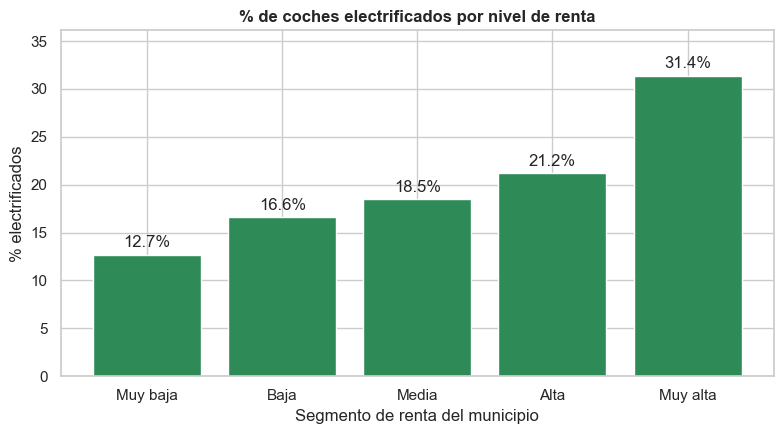

In [9]:
tv.barras_segmento(resumen_h3["pct_electrificado"], "% de coches electrificados por nivel de renta",
                "% electrificados", color="seagreen", es_pct=True)

> 🟢 **Qué esperamos ver:** el porcentaje de electrificados se dispara con la renta (más que
> se duplica entre extremos). Es la señal más fuerte de todo el estudio.

---
## 6. H4 — ¿Se concentran las marcas de gama alta en los municipios ricos?

Usamos la columna booleana `es_gama_alta` (creada a partir de la lista ilustrativa de
marcas) y calculamos su porcentaje por segmento.

In [10]:
resumen_h4 = (df_renta.groupby("segmento_renta", observed=True)["es_gama_alta"]
              .agg(n_coches="size", pct_gama_alta="mean")
              .reindex(ORDEN_SEG))
resumen_h4["pct_gama_alta"] = (resumen_h4["pct_gama_alta"] * 100).round(1)
display(resumen_h4)

gb, ga = resumen_h4.loc["Muy baja", "pct_gama_alta"], resumen_h4.loc["Muy alta", "pct_gama_alta"]
print(f"% gama alta: Muy baja {gb:.1f}%  ->  Muy alta {ga:.1f}%  ({ga-gb:+.1f} puntos)")

,n_coches,pct_gama_alta
segmento_renta,,
Muy baja,525008,15.1
Baja,576500,13.6
Media,1009945,14.1
Alta,972820,16.1
Muy alta,2418559,19.5


% gama alta: Muy baja 15.1%  ->  Muy alta 19.5%  (+4.4 puntos)


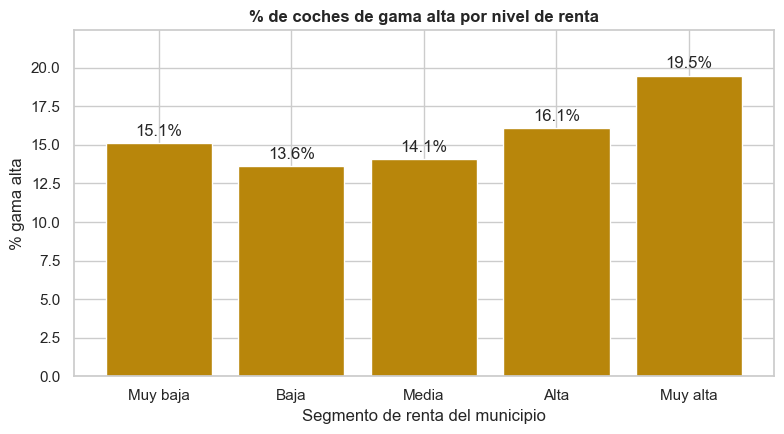

In [11]:
tv.barras_segmento(resumen_h4["pct_gama_alta"], "% de coches de gama alta por nivel de renta",
                "% gama alta", color="darkgoldenrod", es_pct=True)

> 🟢 **Qué esperamos ver:** una subida leve (unos pocos puntos). La gama alta pesa algo más
> en los municipios ricos, pero la diferencia es pequeña: es una tendencia, no un abismo.

---
## 7. H5 — El renting como factor distorsionador

Dos pasos, los dos descriptivos:

1. **Comparar** el coche en renting frente al resto (¿es más nuevo, más potente, más
   electrificado?).
2. **Comprobar** si la relación renta↔coche se mantiene cuando miramos **solo los coches que
   NO son de renting**. Si el patrón sigue ahí, la renta tiene efecto por sí misma.

In [12]:
# Paso 1: renting (SI) vs resto (NO). Excluimos los DESCONOCIDO.
df_rent = df[df["renting"].isin(["SI", "NO"])].copy()
df_rent["renting"] = df_rent["renting"].cat.remove_unused_categories()

resumen_h5 = df_rent.groupby("renting", observed=True).agg(
    n_coches=("antiguedad", "size"),
    antiguedad_media=("antiguedad", "mean"),
    potencia_media=("potencia_cv", "mean"))
resumen_h5["pct_electrificado"] = (df_rent.groupby("renting", observed=True)["es_electrificado"].mean() * 100)
display(resumen_h5.round(2))

,n_coches,antiguedad_media,potencia_media,pct_electrificado
renting,,,,
NO,5694075,7.53,125.559998,21.51
SI,805365,1.99,134.979996,50.06


In [13]:
# Paso 2 (control): el patron de renta SOLO en coches que NO son renting
no_rent = df_renta[df_renta["renting"] == "NO"]

control = no_rent.groupby("segmento_renta", observed=True).agg(
    antiguedad_media=("antiguedad", "mean")).reindex(ORDEN_SEG)
control["pct_electrificado"] = (no_rent.groupby("segmento_renta", observed=True)["es_electrificado"]
                                 .mean() * 100).reindex(ORDEN_SEG)
print("Patron de renta SOLO en coches que NO son renting:")
display(control.round(2))

Patron de renta SOLO en coches que NO son renting:


,antiguedad_media,pct_electrificado
segmento_renta,,
Muy baja,8.36,12.89
Baja,7.72,16.92
Media,7.73,18.85
Alta,7.70,19.87
Muy alta,7.42,27.44


> 🟢 **Qué esperamos ver:** en el paso 1, los coches de renting son **mucho más nuevos** (unos
> 2 años frente a ~7,5), algo más potentes y bastante más electrificados. En el paso 2, aun
> quitando el renting, la antigüedad sigue bajando y la electrificación sigue subiendo con la
> renta — es justo lo que muestra el gráfico de barras agrupadas: ambas series suben con la
> renta. Conclusión: el renting **amplifica** el fenómeno, pero la renta tiene efecto propio
> (confusión parcial, no total).

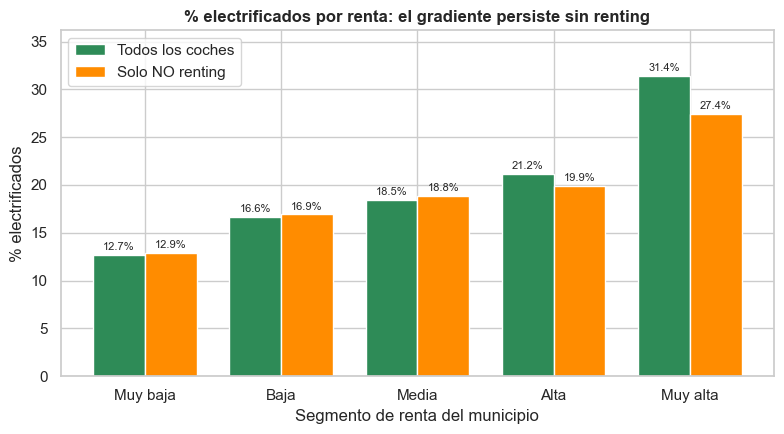

In [14]:
# Grafico del control: el gradiente de renta PERSISTE al quitar el renting.
# Comparamos el % de electrificados por segmento en TODOS los coches frente a
# SOLO los que NO son de renting. Si las dos series suben con la renta, el
# efecto de la renta es propio (el renting lo amplifica, no lo crea).
pct_todos = (df_renta.groupby("segmento_renta", observed=True)["es_electrificado"]
             .mean() * 100)
pct_sin_renting = (no_rent.groupby("segmento_renta", observed=True)["es_electrificado"]
                   .mean() * 100)

tv.barras_comparacion_segmento(
    pct_todos, pct_sin_renting,
    etiqueta_a="Todos los coches", etiqueta_b="Solo NO renting",
    titulo="% electrificados por renta: el gradiente persiste sin renting",
    etiqueta_y="% electrificados", orden_segmentos=ORDEN_SEG, es_pct=True)

> 🟢 **Cómo leer el gráfico:** las barras verdes (todos los coches) y naranjas
> (quitando el renting) suben las dos con la renta. Que el patrón siga ahí incluso
> sin renting es la prueba visual de que la renta tiene efecto propio: el renting
> lo amplifica, no lo inventa. Es la confusión *parcial* que esperábamos en H5.

---
## 8. Vista continua: la renta sin discretizar (validación de la segmentación)

Todo el análisis anterior agrupa por **quintiles de renta** (Muy baja → Muy alta). Es una
lente clara y comunicativa, pero discretizar una variable continua tiene un riesgo: que el
gradiente dependa de **dónde trazamos las fronteras** de los cinco grupos.

Para descartarlo, miramos la relación con la **renta como variable continua**, agregando a
nivel **municipio** (un punto por municipio, porque la renta es un dato municipal). Si la
nube se inclina en la misma dirección que el gradiente por segmentos, el patrón es real y no
un artefacto de la segmentación.

In [15]:
# Agregacion a nivel municipio (la renta es constante dentro de cada municipio)
muni = (df_renta.groupby("nombre_municipio", observed=True)
        .agg(renta=("renta_neta_persona", "mean"),
             pct_electrificado=("es_electrificado", "mean"),
             antiguedad_media=("antiguedad", "mean"))
        .reset_index())
muni["pct_electrificado"] *= 100
print(f"Municipios: {len(muni)}")

Municipios: 273


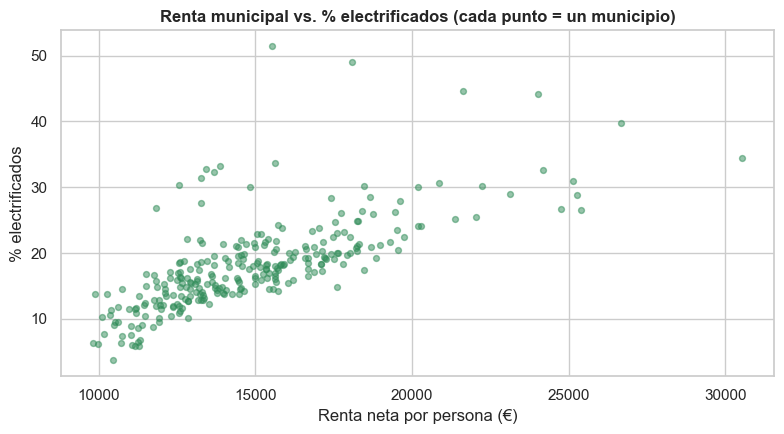

In [16]:
# Senal mas fuerte (H3): renta vs % electrificados
tv.dispersion_municipio(muni, x="renta", y="pct_electrificado",
    titulo="Renta municipal vs. % electrificados (cada punto = un municipio)",
    etiqueta_x="Renta neta por persona (€)", etiqueta_y="% electrificados")

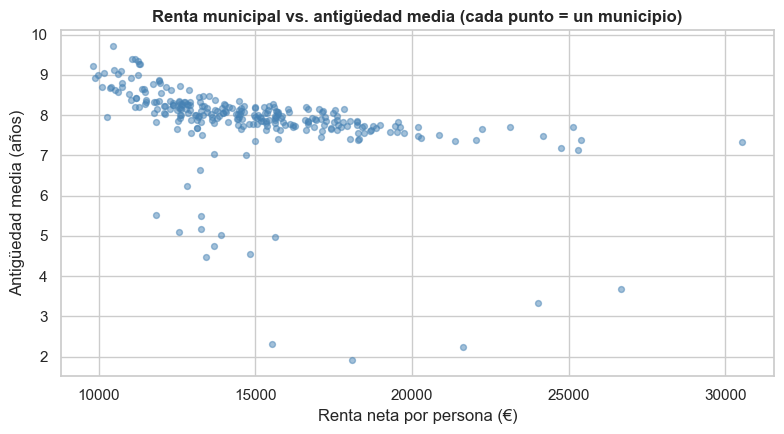

In [17]:
# Senal simetrica (H2): renta vs antiguedad media
tv.dispersion_municipio(muni, x="renta", y="antiguedad_media", color="steelblue",
    titulo="Renta municipal vs. antigüedad media (cada punto = un municipio)",
    etiqueta_x="Renta neta por persona (€)", etiqueta_y="Antigüedad media (años)")

> 🟢 **Qué vemos:** la nube sube con claridad — a más renta municipal, mayor % de
> electrificados — exactamente la misma dirección que el gradiente por quintiles (H3). La
> dispersión crece en la parte alta porque hay menos municipios muy ricos, pero la tendencia
> es inequívoca. En antigüedad ocurre lo simétrico: la nube se inclina a la baja con la renta
> (H2). 
>
> Conclusión: el resultado **no depende de cómo discretizamos** la renta; los quintiles
> solo eran la forma de contarlo de manera sencilla.
>
> Los municipios despegados hacia abajo/arriba encajan con zonas de fuerte presencia de renting (H5).

---
## 9. Resumen del análisis descriptivo

| Hipótesis | Métrica comparada | Resultado (Muy baja → Muy alta) | Veredicto |
|---|---|---|---|
| **H1** | Potencia / cilindrada media | Potencia sube poco; cilindrada plana | Se cumple a medias |
| **H2** | Antigüedad media | Baja con claridad (~2 años menos) | Se cumple |
| **H3** | % electrificados | Más que se duplica | Se cumple (señal fuerte) |
| **H4** | % marcas gama alta | Sube unos pocos puntos | Tendencia leve |
| **H5** | Renting vs. resto | Renting mucho más nuevo/electrificado; el efecto renta persiste sin renting | Confusión parcial |

*(Los números exactos salen en las celdas de arriba al ejecutar.)*

---
## 10. Preparación de datos para Power BI

Aunque el análisis ya está cerrado, terminamos esta fase dejando los datos
**listos para el dashboard**. El dataset analítico tiene 6,6 M de filas:
conectarlo directamente a Power BI sería mala práctica por tres motivos.

1. **Rendimiento.** Cargar y *refrescar* 6,6 M de filas en Power BI es lento y
   consume mucha memoria, sin que aporte nada al cuadro de mando.
2. **Grano innecesario.** El dashboard no razona coche a coche: filtra y compara
   por **municipio, año, segmento de renta y tipo de combustible**. Ese es el
   grano útil; el resto es detalle que no se va a mostrar.
3. **Modelo limpio.** Pre-agregar nos deja unas pocas tablas pequeñas, cada una
   pensada para una visualización concreta (un esquema en estrella simplificado),
   más fácil de mantener y de explicar.

Por eso exportamos **tres tablas agregadas**, cada una con su propósito:

| Tabla | Grano | Para qué sirve en el dashboard |
|---|---|---|
| `resumen_municipio` | Municipio (~273 filas) | Mapa por municipio y dispersión **renta vs. métrica** |
| `resumen_segmento_anio` | Segmento × año | Línea de **evolución temporal** (electrificación) |
| `resumen_segmento_combustible` | Segmento × combustible | Gráfico de **composición** del parque |

El municipio es el grano natural de la tabla principal porque **la renta es un
dato municipal**: bajar de ahí no aportaría información nueva, y subir (a
provincia, p. ej.) se hace en el propio Power BI.

Cada tabla se guarda en **CSV con convención española** (`;`, coma decimal y BOM
`utf-8-sig`, para que Excel y Power BI la lean bien con tildes), y la principal
también en **Parquet** (tipos exactos y más ligera). El guardado se delega en
`tfm_io` (`guardar_csv_es` y `guardar_parquet`) para no repetir la configuración.

In [18]:
# ----------------------------------------------------------------------------------
# TABLA 1 — Resumen por MUNICIPIO (grano para mapas y dispersion renta vs metrica)
# ----------------------------------------------------------------------------------
resumen_municipio = (df_renta.groupby("cod_municipio", observed=True)
    .agg(provincia=("provincia", "first"),
         nombre_municipio=("nombre_municipio", "first"),
         segmento_renta=("segmento_renta", "first"),
         renta_neta_persona=("renta_neta_persona", "first"),
         n_vehiculos=("marca", "size"),
         potencia_cv_media=("potencia_cv", "mean"),
         antiguedad_media=("antiguedad", "mean"),
         pct_electrificado=("es_electrificado", "mean"),
         pct_gama_alta=("es_gama_alta", "mean"),
         pct_renting=("es_renting", "mean"),
         n_electrificados=("es_electrificado", "sum"),
         n_gama_alta=("es_gama_alta", "sum"),
         n_renting=("es_renting", "sum"))
    .reset_index())

for col in ["pct_electrificado", "pct_gama_alta", "pct_renting"]:
    resumen_municipio[col] = resumen_municipio[col] * 100
resumen_municipio = resumen_municipio.round(2)

print(f"Tabla por municipio: {resumen_municipio.shape[0]} filas x {resumen_municipio.shape[1]} columnas")
display(resumen_municipio.head())

Tabla por municipio: 273 filas x 14 columnas


,cod_municipio,provincia,nombre_municipio,segmento_renta,renta_neta_persona,n_vehiculos,potencia_cv_media,antiguedad_media,pct_electrificado,pct_gama_alta,pct_renting,n_electrificados,n_gama_alta,n_renting
0,03005,03,Albatera,Muy baja,10399.0,3562,123.930000,8.69,11.43,16.28,0.00,407,580,0
1,03009,03,Alcoi/Alcoy,Baja,13256.0,16836,118.720001,8.10,12.92,14.93,0.00,2176,2513,0
2,03011,03,"Alfàs del Pi, l'",Muy baja,12274.0,7114,127.660004,8.35,16.25,17.94,0.00,1156,1276,0
3,03014,03,Alacant/Alicante,Media,13681.0,98224,122.349998,7.81,19.52,16.77,0.17,19173,16469,165
4,03015,03,Almoradí,Muy baja,10104.0,6149,122.029999,8.69,10.31,16.72,0.02,634,1028,1


In [19]:
# ----------------------------------------------------------------------------------------------------
# TABLA 2 — Resumen por SEGMENTO x AÑO, agrupada por CÓDIGO de provincia (para la evolucion temporal)
# ----------------------------------------------------------------------------------------------------
resumen_segmento_anio = (df_renta.groupby(
        ["provincia", "segmento_renta", "anio_matriculacion"], observed=True)
    .agg(n_vehiculos=("marca", "size"),
         potencia_cv_media=("potencia_cv", "mean"),
         antiguedad_media=("antiguedad", "mean"),
         pct_electrificado=("es_electrificado", "mean"))
    .reset_index())
resumen_segmento_anio["pct_electrificado"] *= 100
resumen_segmento_anio = resumen_segmento_anio.round(2)

print(f"Tabla segmento x anio: {resumen_segmento_anio.shape[0]} filas x {resumen_segmento_anio.shape[1]} columnas")
display(resumen_segmento_anio.head())

Tabla segmento x anio: 357 filas x 7 columnas


,provincia,segmento_renta,anio_matriculacion,n_vehiculos,potencia_cv_media,antiguedad_media,pct_electrificado
0,03,Muy baja,2010,17672,113.419998,15.78,0.75
1,03,Muy baja,2011,16081,117.849998,14.75,1.30
2,03,Muy baja,2012,14093,117.750000,13.77,1.33
3,03,Muy baja,2013,14576,116.160004,12.75,1.73
4,03,Muy baja,2014,17432,115.620003,11.74,1.31


In [20]:
# ----------------------------------------------------------------------
# TABLA 3 — Resumen por SEGMENTO x TIPO DE COMBUSTIBLE, con CÓDIGO de provincia (composicion del parque)
# ----------------------------------------------------------------------
resumen_segmento_combustible = (df_renta.groupby(
        ["provincia", "segmento_renta", "tipo_combustible"], observed=True)
    .agg(n_vehiculos=("marca", "size")).reset_index())

# % que representa cada combustible DENTRO de su provincia + segmento (vectorizado con transform)
total_seg = (resumen_segmento_combustible
             .groupby(["provincia", "segmento_renta"], observed=True)["n_vehiculos"]
             .transform("sum"))
resumen_segmento_combustible["pct_del_segmento"] = (
    resumen_segmento_combustible["n_vehiculos"] / total_seg * 100).round(2)

print(f"Tabla segmento x combustible: {resumen_segmento_combustible.shape[0]} filas")
display(resumen_segmento_combustible.head())

Tabla segmento x combustible: 190 filas


,provincia,segmento_renta,tipo_combustible,n_vehiculos,pct_del_segmento
0,03,Muy baja,BIOMETANO,1,0.00
1,03,Muy baja,DESCONOCIDO,9,0.00
2,03,Muy baja,DIESEL,118507,42.03
3,03,Muy baja,ELECTRICO,5579,1.98
4,03,Muy baja,ETANOL,4,0.00


In [21]:
# ----------------------------------------------------------------------
# EXPORTACIÓN (CSV en español + Parquet de la tabla principal)
# Usamos las funciones de tfm_io para centralizar el formato y no repetirlo.
# ----------------------------------------------------------------------
ti.guardar_csv_es(resumen_municipio,            DIR_PROCESSED / "powerbi_resumen_municipio.csv")
ti.guardar_csv_es(resumen_segmento_anio,        DIR_PROCESSED / "powerbi_resumen_segmento_anio.csv")
ti.guardar_csv_es(resumen_segmento_combustible, DIR_PROCESSED / "powerbi_resumen_segmento_combustible.csv")

# La tabla principal, ademas, en Parquet (tipos exactos, mas ligero)
ti.guardar_parquet(resumen_municipio, DIR_PROCESSED / "powerbi_resumen_municipio.parquet")

Guardado: ..\data\processed\powerbi_resumen_municipio.csv  (273 filas, 22.4 KB)
Guardado: ..\data\processed\powerbi_resumen_segmento_anio.csv  (357 filas, 13.5 KB)
Guardado: ..\data\processed\powerbi_resumen_segmento_combustible.csv  (190 filas, 5.1 KB)
Guardado: ..\data\processed\powerbi_resumen_municipio.parquet  (273 filas, 25.9 KB)


> 🟢 **Nota sobre las tablas exportadas.** Para optimizar el dashboard, cada tabla se ha agrupado a medida para su visualización: por municipio, por año o por combustible.
>  Las medias (como la antigüedad) están calculadas a nivel municipal. Por tanto, cualquier cálculo general que hagamos después en Power BI tiene que estar ponderado por el número de vehículos (`n_vehiculos`). Si hiciéramos una media normal, estaríamos dando el mismo peso estadístico a un municipio muy pequeño que a una gran ciudad, lo cual falsearía los resultados.

---
**Siguiente fase — Dashboard (Power BI).** Construir el cuadro de mando operativo conectando
estas tablas: KPIs por nivel de renta, mapa por municipio, evolución temporal de la
electrificación y filtros cruzados por provincia, año y segmento de renta.